<a href="https://colab.research.google.com/github/rustamli-nazrin/DevJoint/blob/main/Statistik_Analiz_v%C9%99_Hipotez_Testi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistik Analiz və Hipotez Testi

## Layihənin ümumi təsviri

Bu layihədə Turbo.az platformasından toplanmış avtomobil elanları dataseti üzərində statistik analiz və hipotez testləri aparılmışdır. Dataset müxtəlif avtomobil xüsusiyyətlərini, o cümlədən qiymət, marka, model, istehsal ili, yürüş, sürətlər qutusu, satış növü və digər texniki məlumatları əhatə edir.


Layihənin əsas məqsədi statistik metodlardan istifadə etməklə biznes baxımından əhəmiyyətli suallara cavab tapmaqdır. Bunun üçün əvvəlcə qruplar üzrə təsviri statistika hesablanmış, daha sonra parametrik testlərin fərziyyələri (normallıq və dispersiyaların bərabərliyi) yoxlanılmış və uyğun statistik testlər tətbiq edilmişdir.

Bu notebook aşağıdakı biznes suallarını araşdırır:

1. Salon (Dealer) tərəfindən satılan avtomobillərin orta satış qiyməti fərdi satıcıların (Private) avtomobillərindən statistik cəhətdən yüksəkdirmi?

2. Sürətlər qutusu növü avtomobillərin orta satış qiymətinə statistik cəhətdən təsir göstərirmi?



##STEP 1 — Import libraries and load dataset

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind, f_oneway, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
import warnings
warnings.filterwarnings("ignore")

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sehriyarmemmedli/turboaz-cars-project")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'turboaz-cars-project' dataset.
Path to dataset files: /kaggle/input/turboaz-cars-project


In [50]:
# faylı oxuyuruq
import os

files = os.listdir(path)
print("Downloaded files:", files)


file_name = files[0]
file_path = os.path.join(path, file_name)

cars_df = pd.read_csv(file_path)


Downloaded files: ['cars.csv']


##Step 2: Datasetin ilkin yoxlanılması  

In [51]:
# Datasetin ilk 5 sətrini göstərərək məlumatın ümumi strukturunu yoxlayırıq
cars_df.head()

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,attributes,production_year,engine_displacement_num,engine_displacement_unit,kilometrage_num,kilometrage_unit,barter,loan,salon,spare_parts,vip,featured,img_url,id_y,cars_id,car_rel_url_y,datetime,description,price_y,currency_y,owner_name,shop_name,phone,updated,views,vin,car_details_id_x,Ban növü,Buraxılış ili,Hansı bazar üçün yığılıb,Marka,Model,Mühərrik,Qəzalı,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,"2008, 1.6 L, 270 000 km",2008,1.6,L,270000,km,NaN,NaN,NaN,NaN,NaN,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:40:28.618345+00,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,NaN,507687355.0,13.09.2024,492,NaN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008,NaN,Hyundai,i30,1.6 L/115 a.g./Dizel,NaN,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2024, 1.7 L, 0 km",2024,1.7,L,0,km,NaN,NaN,Salon,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:40:28.618345+00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,NaN,Lada Azərbaycan,554092445.0,13.09.2024,60189,NaN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,NaN,Yaşıl,NaN,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2011, 4.0 L, 164 750 km",2011,4.0,L,164750,km,NaN,NaN,NaN,NaN,vipped-icon,featured-icon,https://turbo.azstatic.com/uploads/f460x343/20...,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:40:28.618345+00,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,NaN,502126242.0,13.09.2024,2473,NaN,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,NaN,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,"2018, 2.0 L, 126 000 km",2018,2.0,L,126000,km,NaN,NaN,NaN,NaN,vipped-icon,NaN,https://turbo.azstatic.com/uploads/f460x343/20...,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:40:28.618345+00,2019 alış\n,26700.0,AZN,Babək,NaN,774999004.0,13.09.2024,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018,NaN,Hyundai,Elantra,2.0 L/150 a.g./Benzin,NaN,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyo

In [52]:
# Sütunların məlumat tiplərini, boş olmayan dəyərlərin sayını və yaddaş istifadəsini yoxlayırıq
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_x                      653721 non-null  object 
 1   car_rel_url_x             653721 non-null  object 
 2   datetime_scrape           653721 non-null  object 
 3   name                      653721 non-null  object 
 4   price_x                   653721 non-null  float64
 5   currency_x                653721 non-null  object 
 6   datetime_product          653721 non-null  object 
 7   city                      653721 non-null  object 
 8   day                       653721 non-null  object 
 9   hour                      653721 non-null  object 
 10  attributes                653721 non-null  object 
 11  production_year           653721 non-null  int64  
 12  engine_displacement_num   653721 non-null  float64
 13  engine_displacement_unit  647933 non-null  o

In [53]:
# Hər sütunda neçə boş (missing) dəyər olduğunu müəyyən edirik
cars_df.isnull().sum()

,0
id_x,0
car_rel_url_x,0
datetime_scrape,0
name,0
price_x,0
currency_x,0
datetime_product,0
city,0
day,0
hour,0


##Step 3 - Qiymətlərin vahid valyutaya çevrilməsi

Datasetdə iki fərqli mənbədən əldə edilmiş **price_x** və **price_y** qiymət sütunları var. Bütün qiymətlər AZN valyutasına çevrilmişdir. Daha sonra hər iki qiymət sütunu müqayisə edilmiş və təxminən **75%-də qiymətlərin tam uyğun olduğu** müəyyən edilmişdir.

Təkcə **16 müşahidədə qiymətlər arasında 5000 AZN-dən çox fərq** aşkar edilmişdir. Bu uyğunsuzluqlar daha etibarlı hesab edilən uyğun mənbənin qiyməti seçilərək düzəldilmişdir. Nəticədə statistik analizlərdə istifadə etmək üçün vahid **price_AZN** sütunu yaradılmışdır.

In [54]:
# ABŞ dollarının (USD) AZN qarşılığını təyin edirik
usd_to_azn = 1.7

# Avronun (EUR) USD qarşılığını təyin edirik
eur_to_usd = 1.1043

# EUR məzənnəsini birbaşa AZN-ə çeviririk
eur_to_azn = usd_to_azn * eur_to_usd

print(eur_to_azn)

1.87731


In [55]:
# currency_x-de olan dəyərlərin sayına baxıram -- təkcəazn saxlaya bilmerik çox dəyər var digərlərində
cars_df["currency_x"].value_counts()

,count
currency_x,
AZN,465598
$,182236
€,5887


In [56]:
# currency_y - də olan dəyərlərin sayı
cars_df["currency_y"].value_counts()

,count
currency_y,
AZN,465596
USD,182239
EUR,5886


In [57]:
# Müxtəlif valyutalarda olan qiymətləri vahid valyuta (AZN) formatına çevirmək üçün funksiya yaradılır.
# Bu, bütün qiymətlərin eyni ölçü vahidində müqayisə edilməsinə imkan verir.
def convert_to_azn(price, currency):

  # Əgər qiymət artıq AZN-dədirsə, olduğu kimi saxlanılır
    if currency == "AZN":
        return price

    elif currency == "$":
        return price * usd_to_azn

    elif currency == "€":
        return price * eur_to_azn

# Tanınmayan valyuta olarsa, boş dəyər qaytarılır
    else:
        return np.nan

In [58]:
# price_x sütunundakı qiymətləri AZN formatına çevirərək yeni sütunda saxlayırıq
cars_df["price_x_azn"] = cars_df.apply(
    lambda row: convert_to_azn(
        row["price_x"],
        row["currency_x"]
    ),
    axis=1
)


# price_y sütunundakı qiymətləri də AZN formatına çeviririk
cars_df["price_y_azn"] = cars_df.apply(
    lambda row: convert_to_azn(
        row["price_y"],
        row["currency_y"]
    ),
    axis=1
)


##Step 4 - İki qiymət mənbəyinin müqayisəsi

In [59]:
# price_x_azn və price_y_azn arasındakı mütləq fərqi hesablayırıq.
# Məqsəd iki mənbə arasında uyğunsuzluq olan qeydləri müəyyən etməkdir.
cars_df["price_difference"] = (
    abs(
        cars_df["price_x_azn"] -
        cars_df["price_y_azn"]
    )
)

In [60]:
# Qiymət fərqlərinin statistik xülasəsini əldə edərək onların paylanmasını qiymətləndiririk
cars_df["price_difference"].describe()

,price_difference
count,465596.000000
mean,0.552387
std,48.525010
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,17200.000000


In [61]:
# Fərqi 5000 AZN-dən çox olan qeydlərin sayını müəyyən edirik.
# Bu qeydlər son qiymət sütunu yaradılarkən ayrıca nəzərə alınacaq.

cars_df[
    cars_df["price_difference"] > 5000
].shape

(8, 59)

##Step 5 - Son qiymət sütununun yaradılması

In [62]:
# Analiz üçün istifadə olunacaq yekun qiymət sütununu yaradırıq.
# Əgər iki mənbə arasındakı fərq 5000 AZN-dən böyükdürsə,
# daha uyğun hesab edilən price_y_azn seçilir, əks halda price_x_azn istifadə olunur.
cars_df["price_azn"] = np.where(
    cars_df["price_difference"] > 5000,
    cars_df["price_y_azn"],
    cars_df["price_x_azn"]
)

In [63]:
# Yaradılmış price_azn sütununun təsviri statistikasına baxırıq.
# Bununla yeni dəyişənin statistik analiz üçün hazır olduğunu yoxlayırıq.
cars_df["price_azn"].describe()

,price_azn
count,653721.000000
mean,41899.329114
std,50023.123797
min,500.000000
25%,17200.000000
50%,27900.000000
75%,47260.000000
max,940000.000000


##Business Question 1
Salon avtomobillərinin orta satış qiyməti fərdi satıcıların avtomobillərindən daha yüksəkdirmi?

##Step 6 - Satıcı növününün yaradılması (Dealer və Private)

In [64]:
# "salon" sütununa əsasən satıcı növünü müəyyən edirik.
# Əgər "salon" məlumatı mövcuddursa avtomobil (Dealer),
# əks halda isə fərdi satıcı (Private) kimi qəbul edilir.
cars_df["seller_type"] = np.where(
    cars_df["salon"].notna(),
    "Dealer",
    "Private"
)

In [65]:
# Yaradılmış seller_type dəyişənində hər qrup üzrə müşahidələrin sayını yoxlayırıq

cars_df["seller_type"].value_counts()

,count
seller_type,
Private,460382
Dealer,193339


##Step 7 - Qruplar üzrə təsviri statistika

In [66]:
# Hər iki satıcı qrupu üzrə əsas təsviri statistikanı hesablayırıq.
# Burada müşahidə sayı, orta qiymət, median və standart sapma əldə edilir.
seller_stats = (
    cars_df
    .groupby("seller_type")["price_azn"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)

seller_stats

,count,mean,median,std
seller_type,,,,
Dealer,193339,65577.750105,42500.0,72850.856242
Private,460382,31955.495002,24300.0,31464.984236


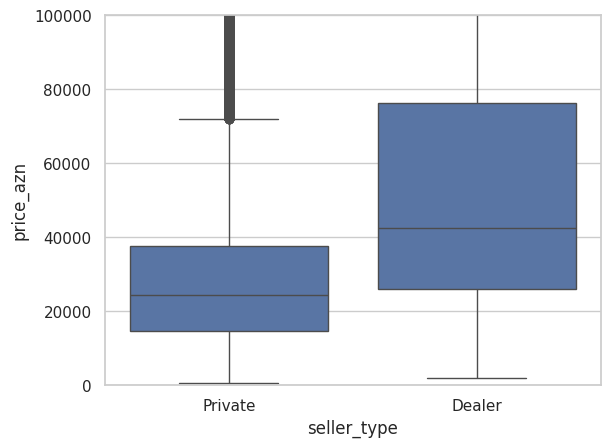

In [67]:
# Hər iki satıcı qrupu üzrə qiymət paylanmasını müqayisə etmək üçün boxplot qururuq.

sns.boxplot(
    data=cars_df,
    x="seller_type",
    y="price_azn"
)

plt.ylim(0,100000)
plt.show()

##Step 7 - Test fərziyyələrinin yoxlanılması

In [83]:
# Hər iki qrup üzrə qiymət paylanmasının asimmetriyasını (skewness) hesablayırıq.

cars_df.groupby(
    "seller_type"
)["price_azn"].skew()

,price_azn
seller_type,
Dealer,3.784987
Private,4.857296


In [69]:
# Dealer və Private qruplarının qiymətlərini ayrıca dəyişənlərdə saxlayırıq
dealer = cars_df[
    cars_df.seller_type=="Dealer"
]["price_azn"]

private = cars_df[
    cars_df.seller_type=="Private"
]["price_azn"]

# Qruplar arasında dispersiyaların bərabər olub-olmadığını Levene testi ilə yoxlayırıq

levene_test = levene(
    dealer,
    private
)

levene_test

LeveneResult(statistic=np.float64(36559.203667093185), pvalue=np.float64(0.0))

In [70]:
# İki qrupun orta qiymətlərini müqayisə etmək üçün t-test tətbiq edirik.
# equal_var=False seçilməsi Levene testində dispersiyalar fərqli olduqda daha etibarlı nəticə verir.
t_test = ttest_ind(
    dealer,
    private,
    equal_var=False,
    alternative="greater"
)

t_test

TtestResult(statistic=np.float64(195.42221685688148), pvalue=np.float64(0.0), df=np.float64(224239.04736121546))

## Independent Samples t-test

Dealer və Private qruplarının orta satış qiymətlərini müqayisə etmək üçün Welch Independent Samples t-test tətbiq edildi.

Bu test iki müstəqil qrupun orta qiymətləri arasında statistik cəhətdən əhəmiyyətli fərqin olub-olmadığını müəyyən etmək üçün istifadə olundu.

## Nəticələrin interpretasiyası

Levene testinin nəticəsinə görə **p-value = 0.000 (< 0.05)** olmuşdur. Bu nəticə Dealer və Private qruplarının dispersiyalarının bərabər olmadığını göstərir. Buna görə də klassik Student t-test əvəzinə **Welch Independent Samples t-test** tətbiq edilmişdir.

Welch t-testinin nəticəsinə əsasən **t = 195.42** və **p-value < 0.001** əldə edilmişdir. Bu nəticə göstərir ki, Dealer və Private qruplarının orta satış qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq mövcuddur. Beləliklə, **Null hipotez (H₀) rədd edilir**, alternativ hipotez (H₁) isə qəbul olunur.

Hesablamalara əsasən Dealer avtomobillərinin orta satış qiyməti Private avtomobillərdən təxminən **33,622 AZN** daha yüksəkdir. Bu fərq həm statistik, həm də praktiki baxımdan əhəmiyyətli görünür.

Lakin bu nəticə **Dealer olmağın avtomobil qiymətini artırdığını sübut etmir**. Salonlarda satılan avtomobillər daha yeni, daha yaxşı vəziyyətdə və ya daha premium markalara aid ola bilər. Buna görə də bu analiz yalnız iki dəyişən arasında **əlaqə (association)** göstərir

#Biznes nəticəsi

Analizin nəticələrinə əsasən salon (Dealer) tərəfindən satılan avtomobillərin orta satış qiyməti fərdi satıcıların avtomobillərindən əhəmiyyətli dərəcədə yüksəkdir.

Bu məlumat bazar iştirakçıları üçün faydalı ola bilər. Məsələn, avtomobil alıcıları salon avtomobillərinin ümumilikdə daha yüksək qiymətə təklif olunduğunu nəzərə ala bilərlər. Satıcılar isə qiymət strategiyalarını müəyyən edərkən satış kanalının qiymətə təsirini qiymətləndirə bilərlər.

Bununla yanaşı, nəticələr səbəb-nəticə əlaqəsini göstərmir. Dealer avtomobillərinin daha baha olmasının əsas səbəbi avtomobilin markası, istehsal ili, yürüşü və digər xüsusiyyətləri ola bilər. Bu səbəbdən daha dəqiq nəticə əldə etmək üçün gələcək analizlərdə bu amillər də nəzərə alınmalıdır.

Aşağıdakı qrafik Dealer və Private satıcıları üzrə orta satış qiymətlərini müqayisə edir. Qrafikdən görünür ki, Dealer tərəfindən satılan avtomobillərin orta satış qiyməti Private satıcılara nisbətən daha yüksəkdir.

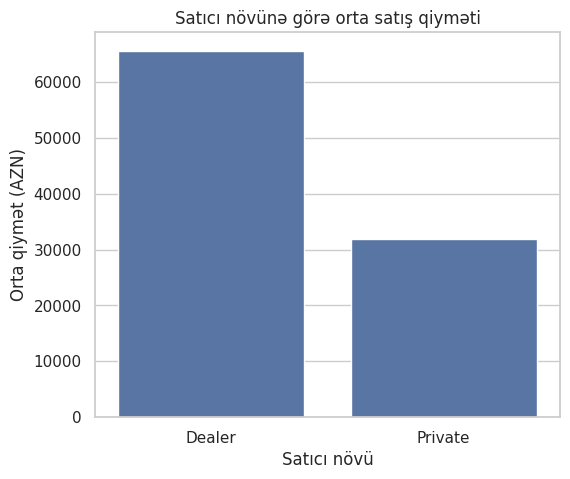

In [81]:
# Dealer və Private qrupları üzrə orta satış qiymətlərini hesablayırıq
seller_mean = (
    cars_df.groupby("seller_type")["price_azn"]
    .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=seller_mean.index,
    y=seller_mean.values
)

plt.title("Satıcı növünə görə orta satış qiyməti")
plt.xlabel("Satıcı növü")
plt.ylabel("Orta qiymət (AZN)")

plt.show()

In [71]:
# Hər iki qrupun orta qiymətləri arasındakı fərqi hesablayırıq
difference = (
    dealer.mean()
    -
    private.mean()
)

difference

np.float64(33622.2551036082)

## **Business Question 2** - Does transmission type affect the average selling price of cars?

In [72]:
cars_df["Sürətlər qutusu"].value_counts()

,count
Sürətlər qutusu,
Avtomat,469853
Mexaniki,95477
Variator,56987
Reduktor,23143
Robot,8261


In [73]:
# Hər sürətlər qutusu növü üzrə müşahidə sayını hesablayırıq.
# Çox az müşahidəsi olan qrupları analizdən çıxarmaq üçün
transmission_counts = (
    cars_df["Sürətlər qutusu"]
    .value_counts()
)

# Etibarlı analiz üçün 1000-dən çox müşahidəsi olan qrupları saxlayırıq.
valid_groups = transmission_counts[
    transmission_counts > 1000
].index

# Filtrlənmiş dataset yaradılır.
trans_df = cars_df[
    cars_df["Sürətlər qutusu"]
    .isin(valid_groups)
]

In [74]:
# Hər sürətlər qutusu növü üzrə əsas təsviri statistikanı hesablayırıq.
trans_stats = (
    trans_df
    .groupby("Sürətlər qutusu")
    ["price_azn"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std"
        ]
    )
)

trans_stats

,count,mean,median,std
Sürətlər qutusu,,,,
Avtomat,469853,46164.908370,30500.0,54612.498477
Mexaniki,95477,17355.352730,12500.0,16330.994444
Reduktor,23143,74346.146161,64090.0,52114.132273
Robot,8261,46277.629275,31400.0,47838.513853
Variator,56987,34039.715486,26500.0,24115.408188



Analizdən əvvəl hər sürətlər qutusu növü üzrə müşahidə sayı yoxlanıldı və etibarlı nəticə əldə etmək üçün yalnız kifayət qədər müşahidəyə malik qruplar saxlanıldı.

Daha sonra hər qrup üzrə müşahidə sayı, orta qiymət, median və standart sapma hesablandı. Bu göstəricilər sürətlər qutusu növləri arasında qiymət fərqlərini ilkin mərhələdə müqayisə etməyə imkan verdi.

Lakin yalnız orta qiymətlərin fərqli görünməsi statistik əhəmiyyət ifadə etmir. Bunun üçün ANOVA testi tətbiq olunacaqdır.

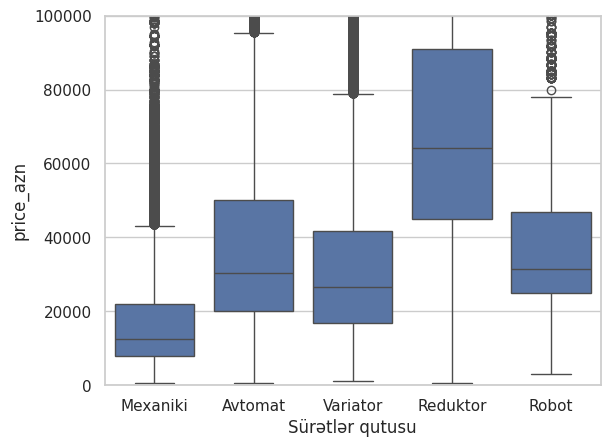

In [75]:
# qiymət paylanmasını müqayisə etmək üçün boxplot qururuq.
sns.boxplot(
    data=trans_df,
    x="Sürətlər qutusu",
    y="price_azn"
)

# Çox yüksək qiymətlər qrafikin oxunu sıxmaması üçün limit təyin edilir.
plt.ylim(0,100000)

plt.show()

## Hipotezlərin qurulması

Bu analizin məqsədi sürətlər qutusu növünün avtomobilin orta satış qiymətinə təsir edib-etmədiyini müəyyən etməkdir.

**Null hipotez (H₀):**
Bütün sürətlər qutusu növlərinin orta satış qiymətləri bərabərdir.

**Alternativ hipotez (H₁):**
Ən azı bir sürətlər qutusu növünün orta satış qiyməti digər qruplardan statistik cəhətdən fərqlənir.

In [76]:
# Hər qrup üzrə qiymət paylanmasının asimmetriyasını qiymətləndiririk.
trans_df.groupby(
"Sürətlər qutusu"
)["price_azn"].skew()

,price_azn
Sürətlər qutusu,
Avtomat,4.798476
Mexaniki,4.906560
Reduktor,5.415143
Robot,4.568986
Variator,2.290834


In [77]:
# ANOVA tətbiq edilməzdən əvvəl qrupların dispersiyalarının bərabərliyi Levene testi ilə yoxlanılır.
groups = [
    group["price_azn"].values
    for name,group
    in trans_df.groupby("Sürətlər qutusu")
]


levene(*groups)

LeveneResult(statistic=np.float64(3430.2103927928592), pvalue=np.float64(0.0))

In [78]:
# Müxtəlif sürətlər qutusu növlərinin orta qiymətləri arasında
# fərq olub-olmadığını müəyyən etmək üçün One-Way ANOVA tətbiq edilir.
anova_result = f_oneway(*groups)

anova_result

F_onewayResult(statistic=np.float64(9976.021041919403), pvalue=np.float64(0.0))

In [79]:
# ANOVA nəticəsi əhəmiyyətli olduqda hansı qrupların bir-birindən fərqləndiyini müəyyən etmək üçün Tukey HSD testi tətbiq edilir.
# Type I səhv riskini azaldır.
tukey = pairwise_tukeyhsd(
    endog=trans_df["price_azn"],
    groups=trans_df["Sürətlər qutusu"],
    alpha=0.05
)

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
 group1   group2    meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------
 Avtomat Mexaniki -28809.5556    0.0 -29279.8123  -28339.299   True
 Avtomat Reduktor  28181.2378    0.0  27289.2782  29073.1974   True
 Avtomat    Robot    112.7209 0.9996  -1357.5005   1582.9423  False
 Avtomat Variator -12125.1929    0.0 -12712.7969 -11537.5888   True
Mexaniki Reduktor  56990.7934    0.0  56020.2073  57961.3795   True
Mexaniki    Robot  28922.2765    0.0  27403.0675  30441.4856   True
Mexaniki Variator  16684.3628    0.0  15983.1324  17385.5931   True
Reduktor    Robot -28068.5169    0.0 -29766.2939 -26370.7399   True
Reduktor Variator -40306.4307    0.0  -41338.988 -39273.8734   True
   Robot Variator -12237.9138    0.0 -13797.4437 -10678.3839   True
-------------------------------------------------------------------


## Nəticələr

Təsviri statistika göstərir ki, sürətlər qutusu növləri arasında orta satış qiymətləri nəzərəçarpacaq dərəcədə fərqlənir. Ən yüksək orta qiymət **Reduktor** tipli avtomobillərdə (74,346 AZN), ən aşağı orta qiymət isə **Mexaniki** sürətlər qutusuna malik avtomobillərdə (17,355 AZN) müşahidə edilmişdir.

Levene testinin nəticəsinə görə **p-value = 0.000 (< 0.05)** olmuşdur. Bu nəticə qrupların dispersiyalarının bərabər olmadığını göstərir. Buna baxmayaraq, böyük seçmə həcmi nəzərə alınaraq One-Way ANOVA testi tətbiq edildi.

ANOVA testinin nəticəsinə əsasən **F = 9976.02** və **p-value < 0.001** əldə edilmişdir. Bu nəticə göstərir ki, sürətlər qutusu növü ilə avtomobilin orta satış qiyməti arasında statistik cəhətdən əhəmiyyətli fərq mövcuddur. Buna görə **Null hipotez (H₀) rədd edilir**, alternativ hipotez (H₁) isə qəbul olunur.

əlavə olaraq Tukey HSD post-hoc testi tətbiq edilmişdir. Tukey testinin nəticələrinə əsasən demək olar ki, bütün sürətlər qutusu növləri arasında orta qiymətlər statistik cəhətdən əhəmiyyətli dərəcədə fərqlənir (**p < 0.05**). Yeganə istisna **Avtomat** və **Robot** sürətlər qutuları olmuşdur. Bu iki qrup arasında orta qiymət fərqi statistik baxımdan əhəmiyyətli deyil (**p = 0.9996**).

Qiymət fərqləri avtomobilin markası, istehsal ili, mühərrik həcmi, yürüşü və digər xüsusiyyətlərlə də əlaqəli ola bilər. Buna görə nəticələr səbəb-nəticə deyil, yalnız statistik əlaqəni göstərir.

# Biznes nəticəsi

Analizin nəticələri göstərir ki, sürətlər qutusu növü avtomobillərin satış qiymətləri ilə statistik cəhətdən əlaqəlidir. Xüsusilə **Reduktor** tipli avtomobillərin orta satış qiyməti digər qruplardan xeyli yüksək, **Mexaniki** sürətlər qutusuna malik avtomobillərin orta qiyməti isə ən aşağı səviyyədədir.

Aşağıdakı qrafik hər sürətlər qutusu növü üzrə orta satış qiymətini göstərir. Vizual olaraq da görünür ki, Reduktor tipli avtomobillərin orta qiyməti ən yüksək, Mexaniki sürətlər qutusuna malik avtomobillərin orta qiyməti isə ən aşağıdır.

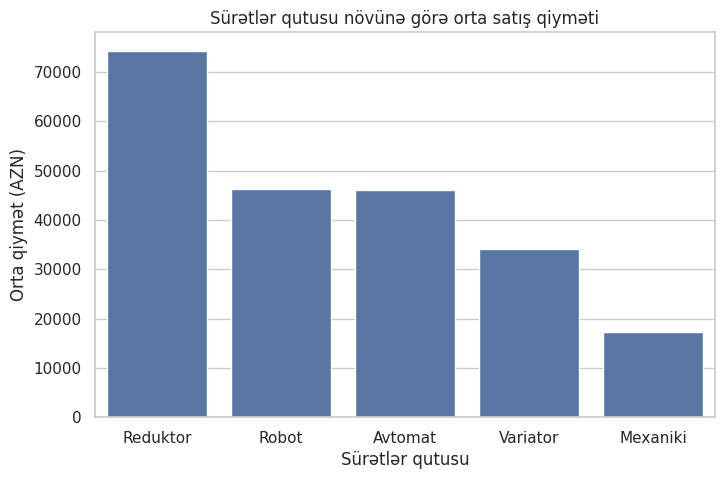

In [80]:
# Hər sürətlər qutusu növü üzrə orta qiyməti hesablayırıq
mean_prices = (
    cars_df.groupby("Sürətlər qutusu")["price_azn"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=mean_prices.index,
    y=mean_prices.values
)

plt.title("Sürətlər qutusu növünə görə orta satış qiyməti")
plt.xlabel("Sürətlər qutusu")
plt.ylabel("Orta qiymət (AZN)")

plt.show()